# Predicción de abandono de clientes (Churn Prediction)

## 1. Descripción del negocio

La empresa se enfrenta a una pérdida constante de clientes (churn). Cuesta considerablemente más adquirir un nuevo cliente que retener a uno existente, por lo que es vital identificar anticipadamente qué usuarios tienen una alta probabilidad de abandonar el servicio o dejar de comprar.

Variable objetivo y tipo:

* Variable Objetivo (Y): abandono (1 = Sí abandona, 0 = No abandona).

* Tipo: Categórica (Clasificación binaria).

**Contexto del negocio y decisiones:**
El modelo permitirá al departamento de marketing y fidelización segmentar a los clientes en riesgo. Con esta predicción, se tomarán decisiones proactivas, como el envío de descuentos personalizados, campañas de re-engagement, o llamadas de servicio al cliente específicas para mitigar las fricciones antes de que ocurra el abandono.

## 2. Mapa de selección de algoritmos

* Paso 1: Tipo de variable objetivo. Al ser una predicción de "Sí" o "No", nos encontramos ante un problema de Clasificación.

* Paso 2: Objetivo de negocio. Identificar la probabilidad de que un cliente pertenezca a la clase "abandono". Las familias aplicables son los modelos lineales generalizados, árboles de decisión y métodos de ensamble.

* Paso 3: Restricciones del contexto. En retención de clientes, la interpretabilidad es fundamental; el negocio necesita saber por qué se van los clientes para diseñar estrategias (no basta con una "caja negra"). El volumen de datos inicial y la velocidad de inferencia requerida son moderados.

* Paso 4: Justificación de algoritmos candidatos:

    1. Regresión Logística:

        * Justificación: Es un estándar en la industria por su alta interpretabilidad. Permite entender el peso exacto (coeficientes) de cada variable (ej. qué tanto influyen las quejas).

        * Limitaciones: Asume una relación lineal entre las variables independientes y el log-odds de la variable objetivo, lo cual puede no cumplirse en la realidad.

    2. Random Forest (Bosques Aleatorios):

        * Justificación: Maneja muy bien relaciones no lineales y es robusto ante datos atípicos (outliers).

        * Limitaciones: Es menos interpretable directamente que la regresión logística (aunque se puede mitigar con la importancia de características).

## 3. Simulación y exploración de datos

,frec_compra,gasto_promedio,tiempo_ultima_compra,interaccion_promos,historial_quejas,uso_canales_digitales,abandono
0,5,117.76,22,0,1,4.3,0
1,4,131.51,30,1,1,3.1,0
2,4,131.25,84,1,1,4.8,0
3,4,134.77,85,0,2,1.2,1
4,2,176.48,44,0,1,9.6,0


C:\Users\raulg\AppData\Local\Temp\ipykernel_12484\3610867327.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='abandono', palette='Set2')
C:\Users\raulg\AppData\Local\Temp\ipykernel_12484\3610867327.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='abandono', y='historial_quejas', palette='Set2')


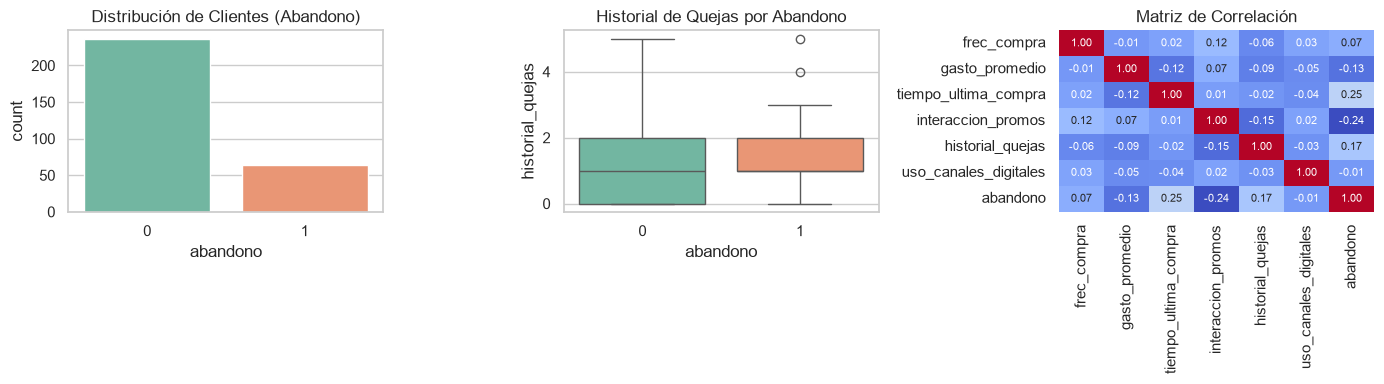

Verificación de balance de clases (Proporción de abandonos):
abandono
0    78.666667
1    21.333333
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# 1. Simulación de datos (300 registros)
np.random.seed(42)
n_samples = 300

# Variables independientes (X)
frec_compra = np.random.poisson(lam=4, size=n_samples) # Compras por mes
gasto_promedio = np.random.normal(loc=120, scale=35, size=n_samples).round(2)
tiempo_ultima_compra = np.random.randint(1, 90, size=n_samples) # Días
interaccion_promos = np.random.binomial(n=1, p=0.4, size=n_samples) # 1=Sí, 0=No
historial_quejas = np.random.poisson(lam=1, size=n_samples)
uso_canales = np.random.uniform(low=0, high=10, size=n_samples).round(1) # Horas al mes

# Generación de la variable objetivo (Y) con cierta lógica de negocio
# Mayor tiempo sin compra y más quejas aumentan la probabilidad de abandono
prob_abandono = (tiempo_ultima_compra / 90) * 0.4 + (historial_quejas / 5) * 0.4 - (interaccion_promos * 0.2)
prob_abandono = np.clip(prob_abandono, 0.05, 0.95) # Limitar entre 5% y 95%
abandono = np.random.binomial(n=1, p=prob_abandono)

# Creación del DataFrame
df = pd.DataFrame({
    'frec_compra': frec_compra,
    'gasto_promedio': gasto_promedio,
    'tiempo_ultima_compra': tiempo_ultima_compra,
    'interaccion_promos': interaccion_promos,
    'historial_quejas': historial_quejas,
    'uso_canales_digitales': uso_canales,
    'abandono': abandono
})

display(df.head())

# 2. Análisis Exploratorio Básico (EDA)
plt.figure(figsize=(14, 4))

# Visualización 1: Distribución del abandono
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='abandono', palette='Set2')
plt.title('Distribución de Clientes (Abandono)')

# Visualización 2: Quejas vs Abandono
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='abandono', y='historial_quejas', palette='Set2')
plt.title('Historial de Quejas por Abandono')

# Visualización 3: Matriz de correlación (Supuesto de multicolinealidad)
plt.subplot(1, 3, 3)
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=False, annot_kws={"size": 8})
plt.title('Matriz de Correlación')

plt.tight_layout()
plt.show()

# 3. Verificación de supuestos
print("Verificación de balance de clases (Proporción de abandonos):")
print(df['abandono'].value_counts(normalize=True) * 100)
# Para la Regresión Logística, verificamos en el heatmap que no haya alta multicolinealidad 
# entre las variables independientes (X), lo cual se cumple (valores bajos entre variables predictoras).